# Day 4: Polymer Chain MD Simulation with GROMACS

This notebook demonstrates how to prepare a solvated polymer system and perform molecular dynamics (MD) simulations using **GROMACS**. The workflow includes energy minimization, NVT equilibration, and NPT equilibration.

We will also visualize the system and analyze the results using **nglview** and **MDAnalysis**.

---

## GROMACS Formats and Models

### GROMACS File Formats
- **`.gro`**: GROMACS coordinate file containing atomic positions and box dimensions.
- **`.top`**: Topology file describing the molecular structure, force field parameters, and system composition.
- **`.tpr`**: Binary input file for GROMACS simulations, generated by `gmx grompp`.
- **`.edr`**: Energy file containing simulation energy data.
- **`.trr`**: Full-precision trajectory file.
- **`.xtc`**: Compressed trajectory file.
- **`.log`**: Log file with simulation details.

### Models Used
- **Force Field**: AMBER03 with TIP3P water model.
- **Polymer**: Random copolymer of PEO and PET.
- **Water**: SPC/E water model.
- **Ions**: Na+ and Cl- ions for neutralization and ionic strength adjustment.

For more details, refer to the [GROMACS Lysozyme Tutorial](http://www.mdtutorials.com/gmx/lysozyme/06_equil.html).

## Step 0: Initialization

This step sets up the environment for the tutorial. It installs required Python packages, creates necessary directories, and defines reusable functions.

**Important:** Run this step only once when starting the notebook or after restarting the kernel.

In [1]:
# --- Lightweight "reset" for clean re-run ---
from IPython.display import clear_output
import importlib, os, sys

clear_output(wait=True)
importlib.invalidate_caches()

# Install required packages
!{sys.executable} -m pip install nglview parmed pandas panedr MDAnalysis > /dev/null

import numpy as np
import nglview as nv
import parmed as pmd
import pandas as pd
import panedr
import matplotlib.pyplot as plt
import MDAnalysis as mda


# Set fixed project root
if "PROJECT_ROOT" not in os.environ:
    os.environ["PROJECT_ROOT"] = os.path.abspath(os.getcwd())

PROJECT_ROOT = os.environ["PROJECT_ROOT"]
print("Project root:", PROJECT_ROOT)

# Create subdirectories
os.makedirs(os.path.join(PROJECT_ROOT, "simulations"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "mdps"), exist_ok=True)
MDP_DIR = os.path.join(PROJECT_ROOT, "mdps")

# Define reusable functions
def run_command(command):
    """Runs a shell command and prints the output."""
    print(f"Executing: {command}")
    os.system(command)


def visualize_trajectory(coordinate_file, trajectory_file=None, show_box=True, box_color='orange', box_opacity=0.8):
    """
    Visualize a molecular structure or trajectory using MDAnalysis with nglview.
    Supports single-frame files (GRO, PDB, MOL2) or trajectories.
    Displays the periodic boundary box if available.

    Parameters:
        coordinate_file (str): Path to coordinate file (PDB, GRO, MOL2, etc.)
        trajectory_file (str, optional): Path to trajectory file (DCD, XTC, TRR, etc.). Default None.
        show_box (bool): Whether to display the periodic box. Default True.
        box_color (str): Color of PBC box. Default 'orange'.
        box_opacity (float): Opacity of PBC box (0.0-1.0). Default 0.3.

    Returns:
        nglview.NGLWidget: Interactive 3D view of the structure or trajectory.
    """
    # Load Universe with or without trajectory
    if trajectory_file:
        u = mda.Universe(coordinate_file, trajectory_file)
    else:
        u = mda.Universe(coordinate_file)

    # Create nglview widget
    view = nv.show_mdanalysis(u)

    # Orthographic camera
    view.camera = 'orthographic'

    # Disable fog and make atoms fully opaque
    view.stage.set_parameters(fog=False)
    for rep in view.representations:
        rep.update_params(opacity=1.0)

    # Add periodic box if requested and available
    if show_box and hasattr(u, 'dimensions') and u.dimensions is not None:
        # MDAnalysis stores dimensions as [lx, ly, lz, alpha, beta, gamma]
        a, b, c, alpha, beta, gamma = u.dimensions
        box_params = [a, b, c, alpha, beta, gamma, 0, 0, 0]
        view.add_unitcell(color=box_color, opacity=box_opacity, box=box_params)

    # Add water as spacefill (or ball+stick)
    view.add_representation('ball+stick', selection='resname SOL')

    return view


def set_simulation_directory(polymer_name, step_name):
    """
    Create and change to the simulation directory for a specific polymer and step.

    Parameters:
        polymer_name (str): Name of the polymer.
        step_name (str): Name of the simulation step (e.g., 'em', 'preeq', 'eq-nvt').

    Returns:
        str: Path to the created directory.
    """
    sim_dir = os.path.join(PROJECT_ROOT, "simulations", polymer_name, step_name)
    os.makedirs(sim_dir, exist_ok=True)
    os.chdir(sim_dir)
    print(f"Changed to simulation directory: {sim_dir}")
    return sim_dir

Project root: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis


# System Generation: Polymer + Water + Ions

This section demonstrates how to prepare the polymer system for molecular dynamics simulations. The workflow includes:
1. Copying the polymer structure and topology files.
2. Solvating the polymer in a water box.
3. Adding ions to neutralize the system and adjust ionic strength.

Each step ensures the system is chemically and physically valid for simulations.

## Step 1: Copy the Initial `.gro` and `.top` Files

### Purpose
Copy the polymer structure (`.gro`) and topology (`.top`) files generated in Day 3 to the current working directory. This ensures the polymer system is ready for further processing.

### Procedure
1. Create a directory for the polymer system.
2. Copy the `.gro` and `.top` files from the Day 3 output folder.
3. Visualize the polymer structure to verify the copied files.

In [2]:
# Set polymer name and create directory
polymer_name = "PEO25_PET25_random"
polymer_dir = os.path.join(PROJECT_ROOT, "simulations", polymer_name)
os.makedirs(polymer_dir, exist_ok=True)
os.chdir(polymer_dir)

# Copy necessary files
copy_gro = f"cp ../../../Day3-gen-polymer-solved/polymers/{polymer_name}/polymer*gro polymer.gro"
copy_top = f"cp ../../../Day3-gen-polymer-solved/polymers/{polymer_name}/topol.top topol.top"
#run_command(copy_gro)
#run_command(copy_top)


In [186]:
# Visualize the polymer structure
visualize_trajectory("polymer.gro")

NGLWidget()

In [86]:
# Pre-Equilibration (NPT at 400 K) on single polymer to reduce the simulation box size 

# Write pre-equilibration parameters to an MDP file
with open("preeq.mdp", "w") as f:
    f.write("""
; Pre-Equilibration Parameters
; ----------------------------
; This MDP file is used for NPT pre-equilibration at 400 K.

; Run parameters
integrator              = md            ; Leap-frog integrator
nsteps                  = 100000        ; Number of steps (100 ps)
dt                      = 0.001         ; Time step (ps)

; Output control
nstxout-compressed      = 5000           ; Write compressed coordinates every 1 ps
nstenergy               = 5000           ; Write energies every 1 ps
nstlog                  = 5000           ; Write log file every 1 ps

; Bonded parameters
constraints             = h-bonds       ; Constrain bonds involving hydrogen
constraint_algorithm    = lincs         ; LINCS algorithm for constraints

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.2           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.2           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.2           ; Short-range electrostatic cutoff (nm)

; Temperature coupling
tcoupl                  = V-rescale     ; Velocity-rescaling thermostat
tc-grps                 = System        ; Coupling group (entire system)
tau_t                   = 0.1           ; Time constant for temperature coupling (ps)
ref_t                   = 400           ; Reference temperature (K)

; Pressure coupling
pcoupl                  = Berendsen     ; Berendsen barostat
pcoupltype              = isotropic     ; Isotropic pressure coupling
tau_p                   = 2.0           ; Time constant for pressure coupling (ps)
ref_p                   = 1.0           ; Reference pressure (bar)
compressibility         = 4.5e-5        ; Compressibility of water (bar^-1)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions

; Velocity generation
gen_vel                 = yes           ; Generate initial velocities
gen_temp                = 400           ; Temperature for Maxwell distribution (K)
gen_seed                = -1            ; Random seed for velocity generation
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f preeq.mdp -c polymer.gro -p topol.top -o preeq.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run pre-equilibration
mdrun_cmd = "gmx mdrun -s preeq.tpr -deffnm polymer_relax -v"
#run_command(mdrun_cmd)
print(f"Run this command in external terminal to execute pre-equilibration: \n {mdrun_cmd}")

Executing: gmx grompp -f preeq.mdp -c polymer.gro -p topol.top -o preeq.tpr -maxwarn 2
Setting the LD random seed to 2079541655

Generated 36 of the 36 non-bonded parameter combinations

Generated 36 of the 36 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Setting gen_seed to 1643820733

Velocities were taken from a Maxwell distribution at 400 K
Analysing residue names:
There are:    30      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

The largest distance between excluded atoms is 0.381 nm between atom 628 and 632

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 400 K

Calculated rlist for 1x1 atom pair-list as 1.200 nm, buffer size 0.000 nm

Set rlist, assuming 4x4 atom pair-list, to 1.200 nm, buffer size 0.000 nm

Note that mdrun will redetermine rlist based on the actual pair-list setup
Calculating fourier grid dimensions for X Y Z
Usin

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block
Command line:
  gmx grompp -f preeq.mdp -c polymer.gro -p topol.top -o preeq.tpr -maxwarn 2


WARNING 1 [file preeq.mdp]:
  The Berendsen barostat does not generate any strictly correct ensemble,
  and should not be used for new production simulations (in our opinion).
  We recommend using the C-rescale barostat instead.

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group System is 2222.00

NOTE 1 [file preeq.mdp]:
  The optimal PME mesh load for parallel simulations is below 0.5
  and for highly parallel simulations between 0.25 and 0.33,
  for higher performance, increase the cut-off and the PME grid spacing.



Th

In [3]:
# Visualize the polymer structure
visualize_trajectory("polymer_relax.gro")

NGLWidget()

## Step 2: Solvate the Polymer System

### Purpose
This step adds a cubic water box around the polymer and solvates the system with SPC/E water molecules. Solvation ensures the polymer is surrounded by a realistic aqueous environment for simulations.

### Procedure
1. Define a cubic box with a 1.0 nm buffer around the polymer.
2. Solvate the box with SPC/E water molecules.
3. Update the topology file to include water parameters.
4. Visualize the solvated structure.

In [92]:
# Define a cubic box with 1.0 nm buffer
editconf_cmd = "gmx editconf -f polymer_relax.gro -o polymer_box.gro -d 1.0 -bt cubic"
run_command(editconf_cmd)

# Solvate the polymer with SPC/E water
solvate_cmd = "gmx solvate -cp polymer_box.gro -cs spc216.gro -o polymer_solv.gro -p topol.top -maxsol 1000"
run_command(solvate_cmd)

# Print instructions for updating the topology file
print(f'''
; Add the following lines to the [ atomtypes ] section of the topology file:
OW           8      16.00    0.0000  A   3.15061e-01  6.36386e-01
HW           1       1.008   0.0000  A   0.00000e+00  0.00000e+00
Na          11      22.99    0.0000  A   3.32840e-01  1.15897e-02
Cl          17      35.45    0.0000  A   4.40104e-01  4.18400e-01

; Include water topology:
#include "amber03.ff/tip3p.itp"

; Include topology for ions:
[ moleculetype ]
; molname       nrexcl
CL              1

[ atoms ]
; id    at type         res nr  residu name     at name  cg nr  charge
1       Cl              1       CL              CL       1      -1.00000

[ moleculetype ]
; molname       nrexcl
NA              1

[ atoms ]
; id    at type         res nr  residu name     at name  cg nr  charge
1       Na              1       NA              NA       1      1.00000
''')


Executing: gmx editconf -f polymer_relax.gro -o polymer_box.gro -d 1.0 -bt cubic
Note that major changes are planned in future for editconf, to improve usability and utility.
Read 875 atoms
Volume: 3657.62 nm^3, corresponds to roughly 1645900 electrons
Velocities found
    system size :  2.697  2.558  3.604 (nm)
    diameter    :  3.881               (nm)
    center      : 10.762 10.255  7.311 (nm)
    box vectors : 16.731 19.042 11.481 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  :3657.62               (nm^3)
    shift       : -7.822 -7.315 -4.371 (nm)
new center      :  2.940  2.940  2.940 (nm)
new box vectors :  5.881  5.881  5.881 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  : 203.36               (nm^3)
Executing: gmx solvate -cp polymer_box.gro -cs spc216.gro -o polymer_solv.gro -p topol.top -maxsol 1000

         based on residue and atom names, since they could not be
         definitively assigned from the information in your i

               :-) GROMACS - gmx editconf, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block
Command line:
  gmx editconf -f polymer_relax.gro -o polymer_box.gro -d 1.0 -bt cubic


Back Off! I just backed up polymer_box.gro to ./#polymer_box.gro.2#

GROMACS reminds you: "A scientific truth does not triumph by convincing its opponents and making them see the light, but rather because its opponents eventually die and a new generation grows up that is familiar with it." (Max Planck)

               :-) GROMACS - gmx solvate, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/p

In [93]:
# Visualize the solvated structure
visualize_trajectory("polymer_solv.gro")

NGLWidget()

In [90]:
!tail topol.top

    854    856    855    858     4  180.0000771  4.6024000  2

[ system ]
; Name
Generic title in water

[ molecules ]
; Compound       #mols
system1              1
SOL              1000


## Step 3: Add Ions to the Simulation Box

### Purpose
Neutralize the system and add Na+ and Cl- ions to achieve a concentration of 0.01 M. This step ensures the system has the correct ionic strength and is electrically neutral.

### Procedure
1. Generate a `.tpr` file for the solvated system.
2. Add ions using `gmx genion` to neutralize the system and adjust ionic strength.
3. Visualize the solvated and ionized structure.

In [94]:
# Generate a .tpr file for ion addition
grompp_cmd = f"gmx grompp -f {MDP_DIR}/minimization.mdp -c polymer_solv.gro -p topol.top -o ions.tpr"
run_command(grompp_cmd)

# Add ions to neutralize the system and adjust ionic strength
genion_cmd = "echo SOL | gmx genion -s ions.tpr -o polymer_solv_ions.gro -p topol.top -pname NA -nname CL -neutral -conc 0.8"
run_command(genion_cmd)


Executing: gmx grompp -f /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/mdps/minimization.mdp -c polymer_solv.gro -p topol.top -o ions.tpr
Setting the LD random seed to -3540386

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

Excluding 2 bonded neighbours molecule type 'SOL'
Analysing residue names:
There are:    30      Other residues
There are:  1000      Water residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

This run will generate roughly 0 Mb of data
Executing: echo SOL | gmx genion -s ions.tpr -o polymer_solv_ions.gro -p topol.top -pname NA -nname CL -neutral -conc 0.8
Will try to add 98 NA ions and 98 CL ions.
Select a continuous group of solvent molecules
Selected 5: 'SOL'

Processing topology
Replacing 196 solute molecules in topology file (topol.top)  by 98 NA and 98 

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block
Command line:
  gmx grompp -f /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/mdps/minimization.mdp -c polymer_solv.gro -p topol.top -o ions.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/mdps/minimization.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group rest is 8622.00
The integrator does not provide

In [6]:
# Visualize the solvated and ionized structure
visualize_trajectory("polymer_solv_ions.gro")
#!tail polymer_solv_ions.gro

NGLWidget()

# Energy Minimization (EM)

### Purpose
Energy minimization is performed to relax the initial structure and remove steric clashes. This step ensures the system is in a stable starting configuration before equilibration.

### Key Parameters
- **Integrator**: Steepest descent minimization.
- **Tolerance**: Maximum force of 10 kJ/mol/nm.
- **Maximum Steps**: 10,000.

The output structure will be used as the starting point for the pre-equilibration step.

In [95]:
# Energy Minimization (EM)
# Create directory for energy minimization
polymer_name = "PEO25_PET25_block"
em_dir = set_simulation_directory(polymer_name,"em")

# Write EM parameters to an MDP file
with open("em.mdp", "w") as f:
    f.write("""
; Energy Minimization Parameters
; ------------------------------
; This MDP file is used for energy minimization to remove steric clashes
; and relax the system before equilibration.

; Run parameters
integrator              = steep         ; Algorithm for energy minimization
emtol                   = 10.0          ; Convergence criterion (kJ/mol/nm)
emstep                  = 0.01          ; Step size for minimization
nsteps                  = 10000         ; Maximum number of steps

; Output control
nstenergy               = 1             ; Frequency to write energies

; Bonded parameters
constraints             = none          ; No constraints during minimization

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.3           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.3           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.3           ; Short-range electrostatic cutoff (nm)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f em.mdp -c ../polymer_solv_ions.gro -p ../topol.top -o em.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run energy minimization
mdrun_cmd = "gmx mdrun -s em.tpr -deffnm em -v"
run_command(mdrun_cmd)

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/em
Executing: gmx grompp -f em.mdp -c ../polymer_solv_ions.gro -p ../topol.top -o em.tpr -maxwarn 2
Setting the LD random seed to -603979818

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

Excluding 2 bonded neighbours molecule type 'SOL'

Excluding 1 bonded neighbours molecule type 'NA'

Excluding 1 bonded neighbours molecule type 'CL'
Analysing residue names:
There are:    30      Other residues
There are:   804      Water residues
There are:   196        Ion residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

The largest distance between excluded atoms is 0.407 nm between atom 671 and 680
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 52x52x52, s

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/em
Command line:
  gmx grompp -f em.mdp -c ../polymer_solv_ions.gro -p ../topol.top -o em.tpr -maxwarn 2

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group rest is 8034.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

NOTE 1 [file em.mdp]:
  The optimal PME mesh load for parallel simulations is below 0.5
  and for highly parallel simulations between 0.25 and 0.33,
  for higher performance, increase the cut-off and the PME grid spacing.



There was 1 NOTE

GROMACS reminds you: "Your assumptions are your windows on the world. Scrub them off every once in a while, or 

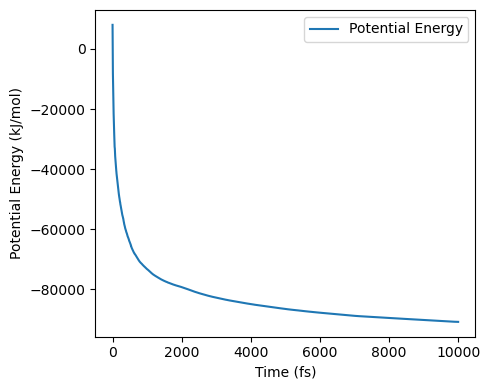

In [189]:
# Plot potential energy during energy minimization
plt.figure(figsize=(5, 4))
df = panedr.edr_to_df(f"{em_dir}/em.edr")
plt.plot(df["Time"], df["Potential"], label="Potential Energy")
plt.xlabel("Time (fs)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# Visualize the minimized structure
visualize_trajectory(f"{em_dir}/em.gro")

NGLWidget()

# Pre-Equilibration (NPT at 400 K)

### Purpose
Pre-equilibration is performed to stabilize the system at constant pressure (1 bar) and elevated temperature (400 K). This step ensures the system is well-relaxed before the main equilibration.

### Key Parameters
- **Integrator**: Leap-frog MD integrator.
- **Pressure Coupling**: Berendsen barostat.
- **Simulation Time**: 100 ps.
- **Temperature**: 400 K.

In [98]:
# Pre-Equilibration (NPT at 400 K)
polymer_name = "PEO25_PET25_block"
preeq_dir = set_simulation_directory(polymer_name, "preeq")

# Write pre-equilibration parameters to an MDP file
with open("preeq.mdp", "w") as f:
    f.write("""
; Pre-Equilibration Parameters
; ----------------------------
; This MDP file is used for NPT pre-equilibration at 400 K.

; Run parameters
integrator              = md            ; Leap-frog integrator
nsteps                  = 100000        ; Number of steps (100 ps)
dt                      = 0.001         ; Time step (ps)

; Output control
nstxout-compressed      = 500           ; Write compressed coordinates every 1 ps
nstenergy               = 500           ; Write energies every 1 ps
nstlog                  = 500           ; Write log file every 1 ps

; Bonded parameters
constraints             = h-bonds       ; Constrain bonds involving hydrogen
constraint_algorithm    = lincs         ; LINCS algorithm for constraints

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.2           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.2           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.2           ; Short-range electrostatic cutoff (nm)

; Temperature coupling
tcoupl                  = V-rescale     ; Velocity-rescaling thermostat
tc-grps                 = System        ; Coupling group (entire system)
tau_t                   = 0.1           ; Time constant for temperature coupling (ps)
ref_t                   = 400           ; Reference temperature (K)

; Pressure coupling
pcoupl                  = Berendsen     ; Berendsen barostat
pcoupltype              = isotropic     ; Isotropic pressure coupling
tau_p                   = 2.0           ; Time constant for pressure coupling (ps)
ref_p                   = 1.0           ; Reference pressure (bar)
compressibility         = 4.5e-5        ; Compressibility of water (bar^-1)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions

; Velocity generation
gen_vel                 = yes           ; Generate initial velocities
gen_temp                = 400           ; Temperature for Maxwell distribution (K)
gen_seed                = -1            ; Random seed for velocity generation
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f preeq.mdp -c ../em/em.gro -p ../topol.top -o preeq.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run pre-equilibration
mdrun_cmd = "gmx mdrun -s preeq.tpr -deffnm preeq -v"
#run_command(mdrun_cmd)
print(f"Run this command in external terminal to execute pre-equilibration: \n {mdrun_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/preeq
Executing: gmx grompp -f preeq.mdp -c ../em/em.gro -p ../topol.top -o preeq.tpr -maxwarn 2
Setting the LD random seed to -1245441

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Setting gen_seed to 636443647

Velocities were taken from a Maxwell distribution at 400 K
Analysing residue names:
There are:    30      Other residues
There are:   804      Water residues
There are:   196        Ion residues
Analysing residue

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/preeq
Command line:
  gmx grompp -f preeq.mdp -c ../em/em.gro -p ../topol.top -o preeq.tpr -maxwarn 2


WARNING 1 [file preeq.mdp]:
  The Berendsen barostat does not generate any strictly correct ensemble,
  and should not be used for new production simulations (in our opinion).
  We recommend using the C-rescale barostat instead.

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group System is 7634.00

NOTE 1 [file preeq.mdp]:
  The optimal PME mesh load for parallel simulations is below 0.5
  and for highly parallel simulations between 0.25 and 0.33,
  for higher performance, increase the cut-off and the PME grid spac

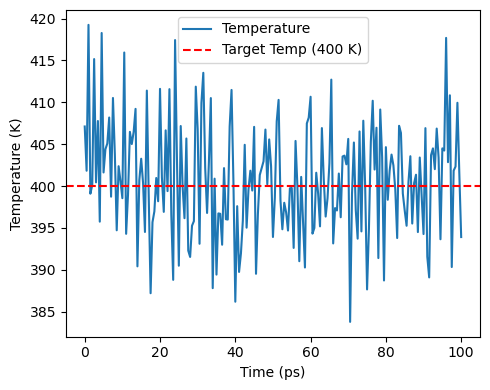

In [100]:
# Plot temperature during pre-equilibration
plt.figure(figsize=(5, 4))
df = panedr.edr_to_df(f"{preeq_dir}/preeq.edr")
plt.plot(df["Time"], df["Temperature"], label="Temperature")
plt.axhline(400, color="red", linestyle="--", label="Target Temp (400 K)")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
# Visualize the pre-equilibrated structure
visualize_trajectory(f"{preeq_dir}/preeq.gro",f"{preeq_dir}/preeq.xtc")

NGLWidget(max_frame=200)

# NVT Equilibration (400 K)

### Purpose
NVT equilibration is performed to stabilize the system at constant volume and temperature (400 K). This step ensures the system reaches thermal equilibrium.

### Key Parameters
- **Integrator**: Leap-frog MD integrator.
- **Simulation Time**: 1000 ps.
- **Temperature**: 400 K.

In [102]:
# NVT Equilibration (400 K)
polymer_name = "PEO25_PET25_block"
nvt_dir = set_simulation_directory(polymer_name, "eq-nvt")

# Write NVT equilibration parameters to an MDP file
with open("eq-nvt.mdp", "w") as f:
    f.write("""
; NVT Equilibration Parameters
; ----------------------------
; This MDP file is used for NVT equilibration at 400 K.

; Run parameters
integrator              = md            ; Leap-frog integrator
nsteps                  = 500000        ; Number of steps (1000 ps)
dt                      = 0.002         ; Time step (ps)

; Output control
nstxout-compressed      = 1000           ; Write compressed coordinates every 2 ps
nstenergy               = 1000           ; Write energies every 2 ps
nstlog                  = 1000           ; Write log file every 2 ps

; Bonded parameters
constraints             = h-bonds       ; Constrain bonds involving hydrogen
constraint_algorithm    = lincs         ; LINCS algorithm for constraints

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.2           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.2           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.2           ; Short-range electrostatic cutoff (nm)

; Temperature coupling
tcoupl                  = V-rescale     ; Velocity-rescaling thermostat
tc-grps                 = System        ; Coupling group (entire system)
tau_t                   = 0.1           ; Time constant for temperature coupling (ps)
ref_t                   = 400           ; Reference temperature (K)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions

; Velocity generation
gen_vel                 = no            ; Do not generate velocities (use velocities from pre-equilibration)
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f eq-nvt.mdp -c ../preeq/preeq.gro -p ../topol.top -o eq-nvt.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run NVT equilibration
mdrun_cmd = "gmx mdrun -s eq-nvt.tpr -deffnm eq-nvt -v"
#run_command(mdrun_cmd)
print(f"Run this command in external terminal to execute NVT-equilibration: \n {mdrun_cmd}")

Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/eq-nvt
Executing: gmx grompp -f eq-nvt.mdp -c ../preeq/preeq.gro -p ../topol.top -o eq-nvt.tpr -maxwarn 2
Setting the LD random seed to -142641186

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from '../preeq/preeq.gro'
Analysing residue names:
There are:    30      Other residues
There are:   804      Water residues
There are:   196        Ion residues
Analysing residues not classified as Protein/DNA/RNA

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4-gmx-md-formats/simulations/PEO25_PET25_block/eq-nvt
Command line:
  gmx grompp -f eq-nvt.mdp -c ../preeq/preeq.gro -p ../topol.top -o eq-nvt.tpr -maxwarn 2

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group System is 7634.00

NOTE 1 [file eq-nvt.mdp]:
  The optimal PME mesh load for parallel simulations is below 0.5
  and for highly parallel simulations between 0.25 and 0.33,
  for higher performance, increase the cut-off and the PME grid spacing.



There was 1 NOTE

GROMACS reminds you: "Stay Cool, This is a Robbery" (Pulp Fiction)



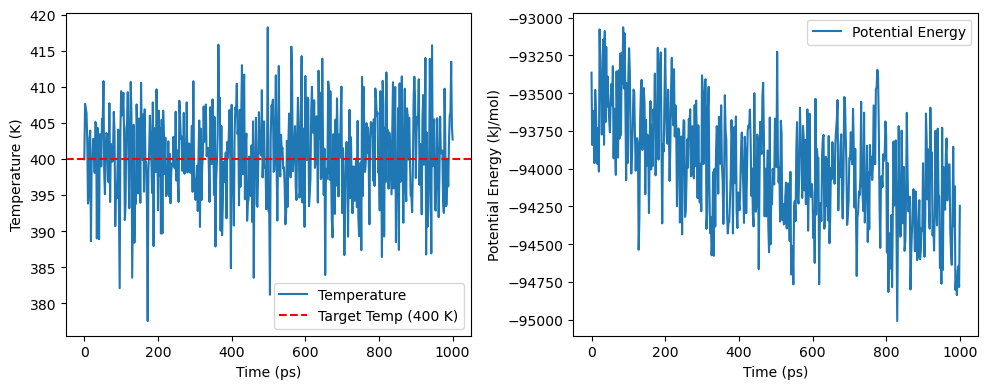

In [103]:
# Plot temperature and potential energy during NVT equilibration
nvt_edr = os.path.join(nvt_dir, "eq-nvt.edr")
df = panedr.edr_to_df(nvt_edr)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(df["Time"], df["Temperature"], label="Temperature")
plt.axhline(400, color="red", linestyle="--", label="Target Temp (400 K)")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["Time"], df["Potential"], label="Potential Energy")
plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (kJ/mol)")
plt.legend()

plt.tight_layout()
plt.show()

In [104]:
# Visualize the NVT equilibrated structure
visualize_trajectory(f"{preeq_dir}/preeq.gro",f"{nvt_dir}/eq-nvt.xtc")

NGLWidget(max_frame=500)

# Equilibration NPT (Simulated Annealing)

### Purpose
NPT equilibration is performed with simulated annealing to stabilize the system at constant pressure (1 bar) while varying the temperature. This step ensures the system is well-equilibrated under realistic conditions.

### Key Parameters
- **Integrator**: Leap-frog MD integrator.
- **Simulation Time**: 1000 ps.
- **Simulated Annealing**: Temperature ramp from 400 K to 600 K and back to 400 K.

In [8]:
# Equilibration NPT (Simulated Annealing)
# Create directory for NPT equilibration
polymer_name = "PEO25_PET25_block"
npt_dir = set_simulation_directory(polymer_name, "eq-npt")

# Write NPT equilibration parameters to an MDP file
with open("eq-npt.mdp", "w") as f:
    f.write("""
; NPT Equilibration Parameters
; ----------------------------
; This MDP file is used for NPT equilibration with simulated annealing.

; Run parameters
integrator              = md            ; Leap-frog integrator
nsteps                  = 500000        ; Number of steps (1000 ps)
dt                      = 0.002         ; Time step (ps)

; Output control
nstxout-compressed      = 500           ; Write compressed coordinates every 1 ps
nstenergy               = 500           ; Write energies every 1 ps
nstlog                  = 500           ; Write log file every 1 ps

; Bonded parameters
constraints             = h-bonds       ; Constrain bonds involving hydrogen
constraint_algorithm    = lincs         ; LINCS algorithm for constraints

; Nonbonded settings
cutoff-scheme           = Verlet        ; Buffered neighbor searching
rlist                   = 1.2           ; Short-range neighbor list cutoff (nm)
rvdw                    = 1.2           ; Short-range van der Waals cutoff (nm)

; Electrostatics settings
coulombtype             = PME           ; Particle Mesh Ewald for long-range electrostatics
rcoulomb                = 1.2           ; Short-range electrostatic cutoff (nm)

; Temperature coupling
tcoupl                  = V-rescale     ; Velocity-rescaling thermostat
tc-grps                 = System        ; Coupling group (entire system)
tau_t                   = 0.1           ; Time constant for temperature coupling (ps)
ref_t                   = 400           ; reference temperature, one for each group, in K
; Simulated annealing
annealing               = single
annealing_npoints       = 4
annealing_time          = 0 600 700 800 ; Set of time steps in (ps)
annealing_temp          = 400 400 600 300   ; Set of temperatures at each time steps

; Pressure coupling
pcoupl                  = Berendsen     ; Berendsen barostat
pcoupltype              = isotropic     ; Isotropic pressure coupling
tau_p                   = 2.0           ; Time constant for pressure coupling (ps)
ref_p                   = 1.0           ; Reference pressure (bar)
compressibility         = 4.5e-5        ; Compressibility of water (bar^-1)

; Periodic boundary conditions
pbc                     = xyz           ; Periodic boundary conditions in all directions

; Velocity generation
gen_vel                 = no
""")

# Step 1: Generate the .tpr file
grompp_cmd = "gmx grompp -f eq-npt.mdp -c ../eq-nvt/eq-nvt.gro -p ../topol.top -o eq-npt.tpr -maxwarn 2"
run_command(grompp_cmd)

# Step 2: Run NPT equilibration
mdrun_cmd = "gmx mdrun -s eq-npt.tpr -deffnm eq-npt -v"
#run_command(mdrun_cmd)
print(f"Run this command in external terminal to execute NVT-equilibration: \n {mdrun_cmd}")

# (Optional Step): Extend the NPT equilibration if the density is not converged
mdrun_cmd2 = "gmx mdrun -s eq-npt.tpr -cpi eq-npt.cpt -deffnm eq-npt -nsteps 100000 -v"
print(f"Run this command in external terminal to extend NPT-equilibration by 100ps: \n {mdrun_cmd2}")


Changed to simulation directory: /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_block/eq-npt
Executing: gmx grompp -f eq-npt.mdp -c ../eq-nvt/eq-nvt.gro -p ../topol.top -o eq-npt.tpr -maxwarn 2
Setting the LD random seed to -600609106

Generated 78 of the 78 non-bonded parameter combinations

Generated 78 of the 78 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'system1'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Taking velocities from '../eq-nvt/eq-nvt.gro'
Analysing residue names:
There are:    30      Other residues
There are:   804      Water residues
There are:   196        Ion residues
Analysing residues not classified 

                :-) GROMACS - gmx grompp, 2025.2-conda_forge (-:

Executable:   /Users/harish/miniconda3/envs/polymer_md/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/harish/miniconda3/envs/polymer_md
Working dir:  /Users/harish/Documents/Work_folder/MetaChem-workshops/polymermd-workshop/Day4,5-gmx-md-simulation-analysis/simulations/PEO25_PET25_block/eq-npt
Command line:
  gmx grompp -f eq-npt.mdp -c ../eq-nvt/eq-nvt.gro -p ../topol.top -o eq-npt.tpr -maxwarn 2


WARNING 1 [file eq-npt.mdp]:
  The Berendsen barostat does not generate any strictly correct ensemble,
  and should not be used for new production simulations (in our opinion).
  We recommend using the C-rescale barostat instead.

Generating 1-4 interactions: fudge = 0.5
Simulated annealing for group System: Single, 4 timepoints
Time (ps)   Temperature (K)
      0.0      400.0
    600.0      400.0
    700.0      600.0
    800.0-     300.0
Number of degrees of freedom in T-Coupling group System is 7634.00

NOTE 1 [file eq-npt.mdp

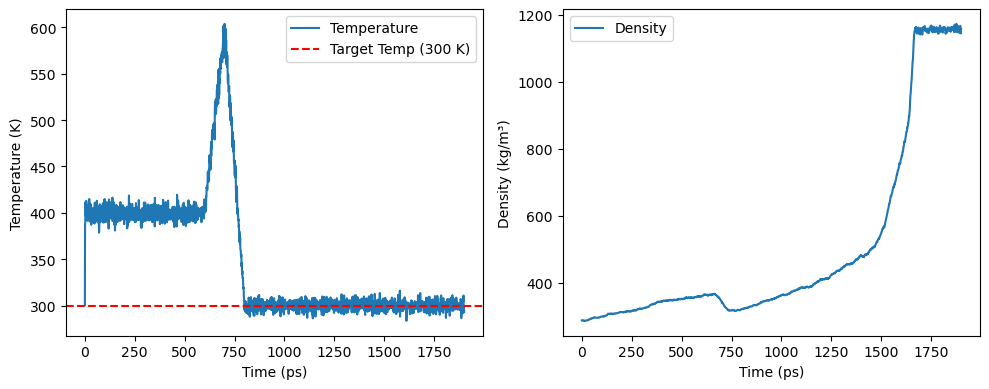

In [183]:
# Plot temperature and volume
npt_edr = os.path.join(npt_dir, "eq-npt.edr")
df = panedr.edr_to_df(npt_edr)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(df["Time"], df["Temperature"], label="Temperature")
plt.axhline(300, color="red", linestyle="--", label="Target Temp (300 K)")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["Time"], df["Density"], label="Density")
plt.xlabel("Time (ps)")
plt.ylabel("Density (kg/m³)")
plt.legend()

plt.tight_layout()
plt.show()
# Un-comment to plot volume in additional plot
#plt.figure(figsize=(5, 4))
#plt.plot(df["Time"], df["Volume"], label="Volume")
#plt.xlabel("Time (ps)")
#plt.ylabel("Volume (nm³)")
#plt.legend()

In [9]:
# Visualize the NPT equilibrated structure
visualize_trajectory(f"{npt_dir}/eq-npt.gro",f"{npt_dir}/eq-npt.xtc")

/Users/harish/miniconda3/envs/polymer_md/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


NGLWidget(max_frame=1900)

### Extract properties using gmx energy

In [78]:
# Run this command in external terminal
ene_cmd="gmx energy -f eq-npt.edr -o energy.xvg"
print(ene_cmd)

gmx energy -f eq-npt.edr -o energy.xvg


This should print out all available energy terms that can be extracted from *.edr file.

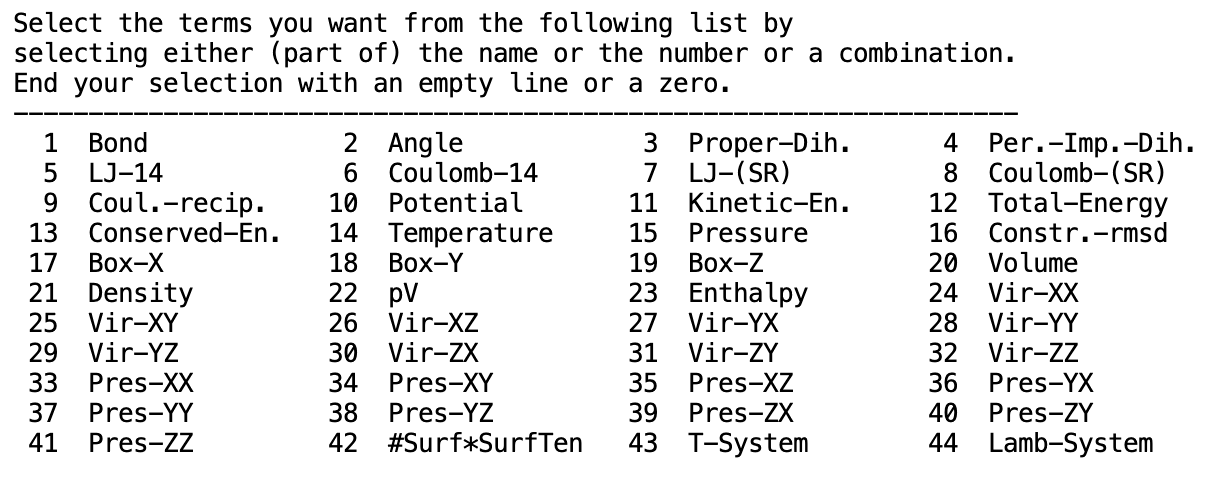

Enter required selection(s) 

- 14: Temperature
- 20: Volume
- 21: Density

To exit the options, press enter again to get statistics for properties:

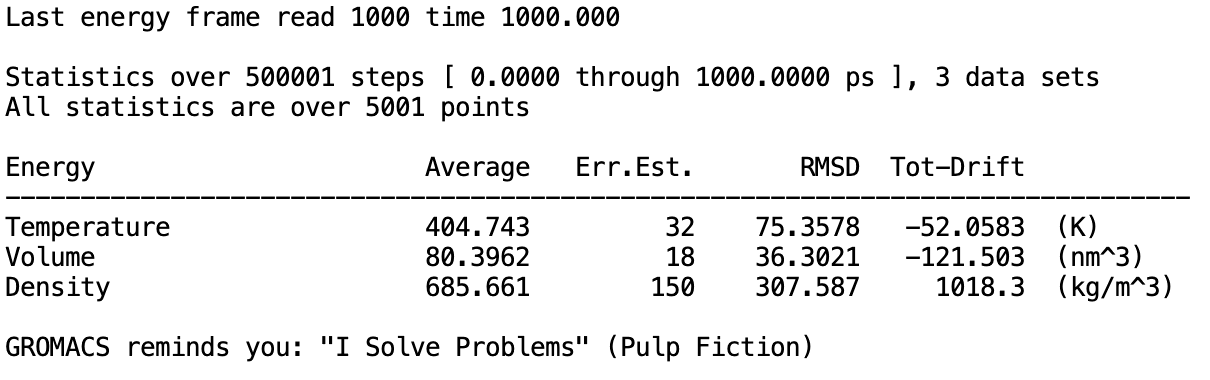

The energy files should look like this:
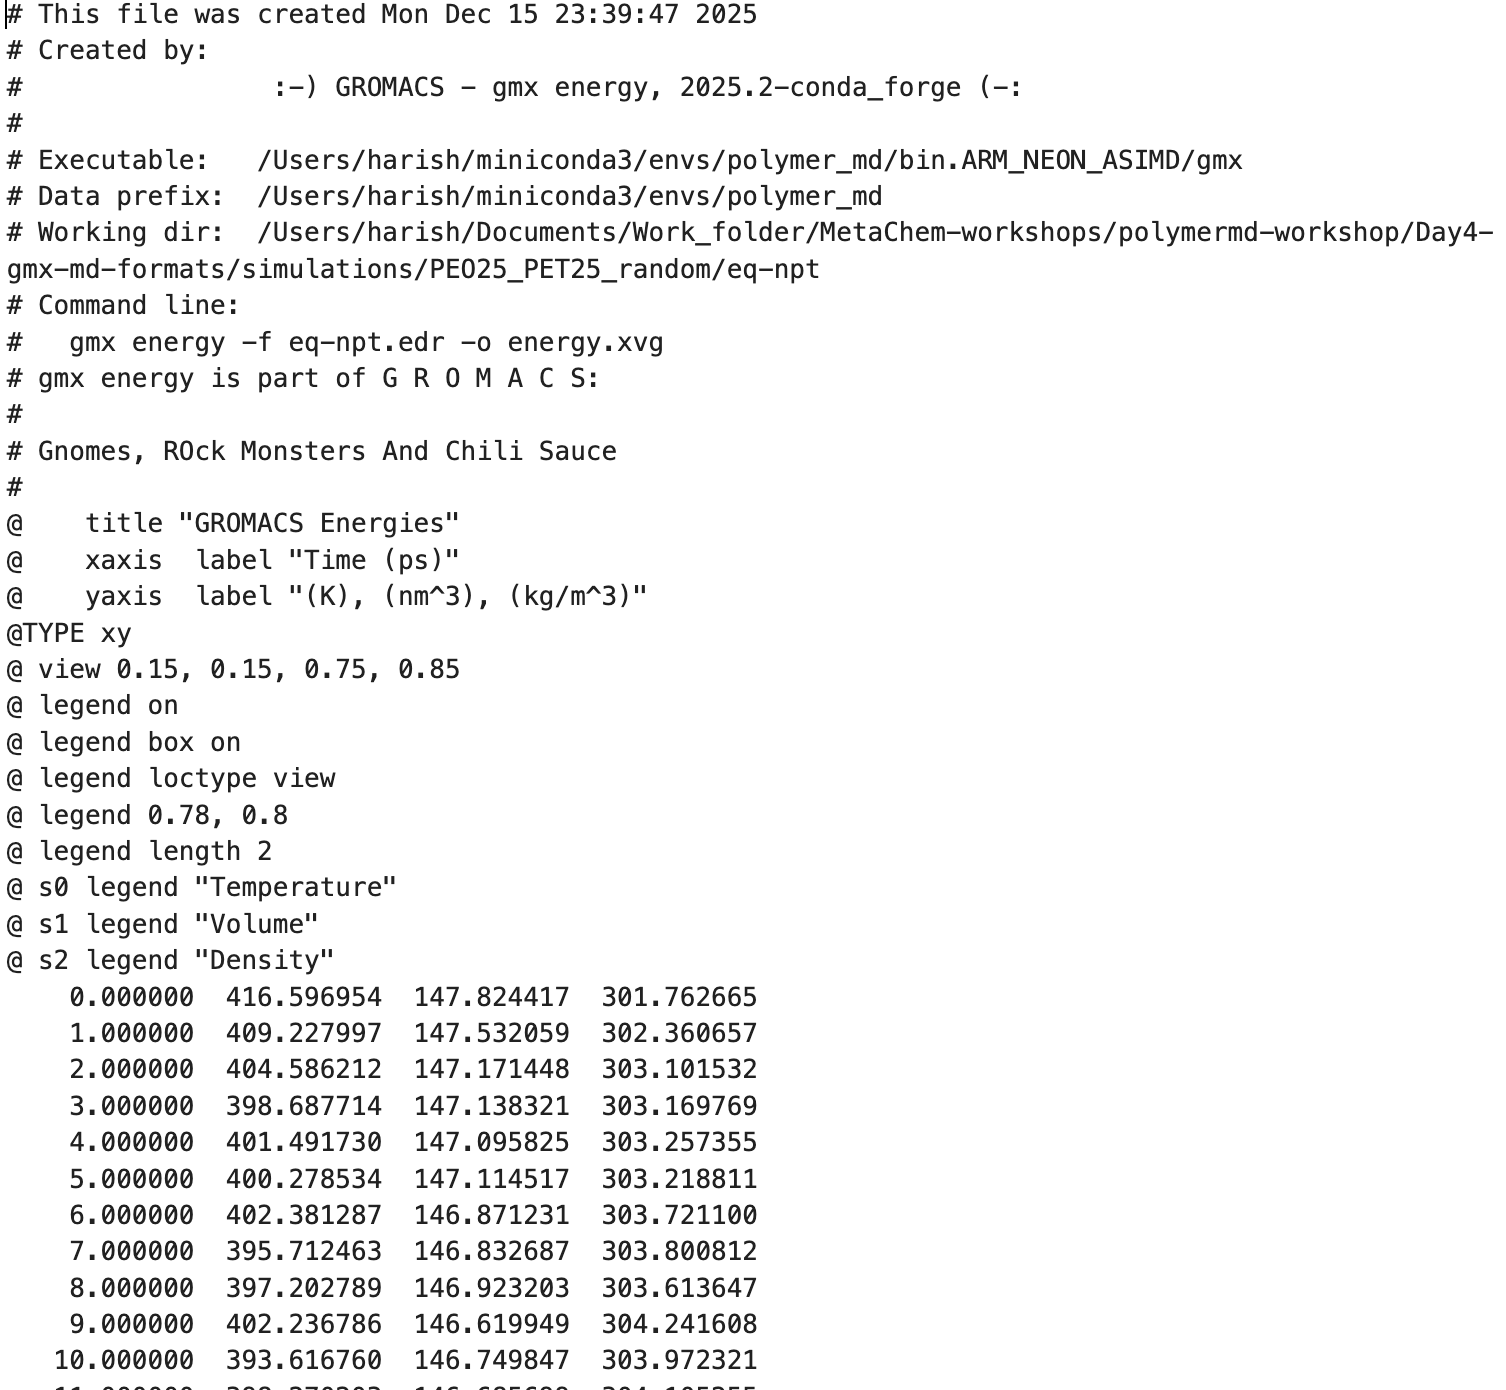


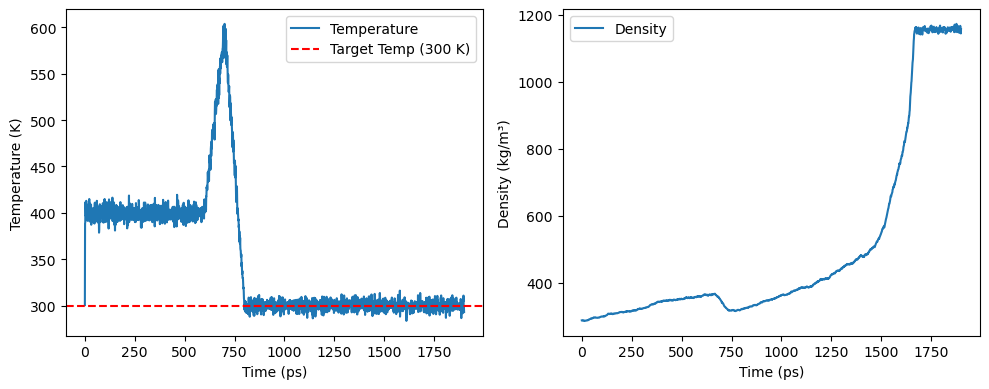

In [184]:
# Plot this using python

import numpy as np
import matplotlib.pyplot as plt

# Load XVG (skip comments)
data = np.loadtxt("energy.xvg", comments=["@", "#"])

time = data[:, 0]        # ps
temperature = data[:, 1]  # K
volume = data[:, 2]      # nm^3
density = data[:, 3]      # kg/m^3

plt.figure(figsize=(10, 4))

# Temperature
plt.subplot(1, 2, 1)
plt.plot(time, temperature, label="Temperature")
plt.axhline(300, color="red", linestyle="--", label="Target Temp (300 K)")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()

# Density
plt.subplot(1, 2, 2)
plt.plot(time, density, label="Density")
plt.xlabel("Time (ps)")
plt.ylabel("Density (kg/m³)")
plt.legend()

plt.tight_layout()
plt.show()
